In [ ]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

# Part A


## The chosen separating hyperplane is:
$$2x_1 + 3x_2 - 5 = 0$$

where  $$
y = \begin{cases}
+1 & \ 2x_1 + 3x_2 - 5 \ge 0 \\
-1 & \ 2x_1 + 3x_2 - 5 < 0
\end{cases}
$$



In [ ]:
X = np.array([
    [.5,.7],
    [1,.6],
    [2.2,1],
    [3,.4],
    [0.8,1.2],
    [0,1]
],dtype='float64')
y = np.array([-1,-1,+1,+1,+1,-1],dtype='int')

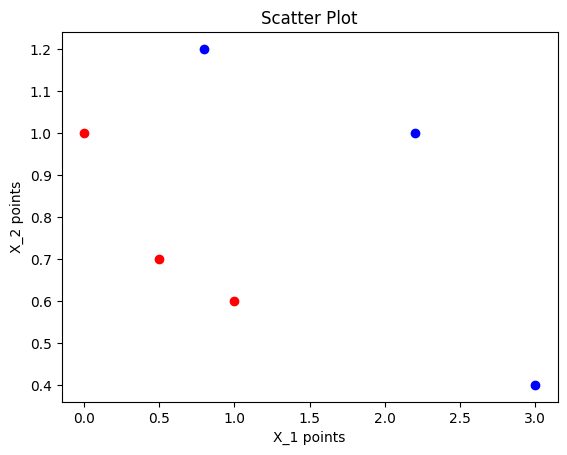

In [ ]:
positive_labels = X[y==1]
negative_labels = X[y==-1]
plt.scatter(positive_labels[:,0],positive_labels[:,1],color='blue')
plt.scatter(negative_labels[:,0],negative_labels[:,1],color='red')
plt.xlabel("X_1 points")
plt.ylabel("X_2 points")
plt.title("Scatter Plot")
plt.show()

# Part B

In [ ]:
# weight and bias vector
weight_vector = np.zeros(3)


In [ ]:
learning_rate = 1

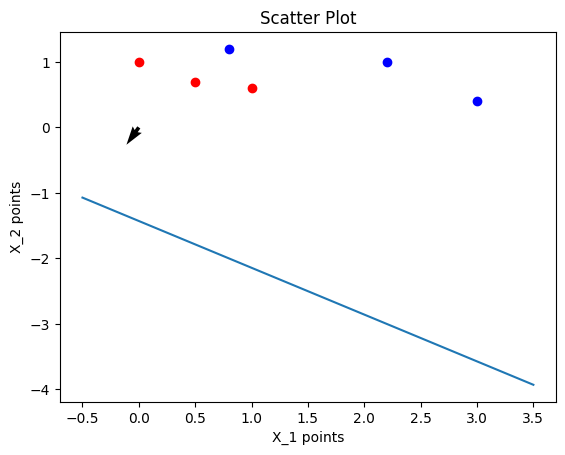

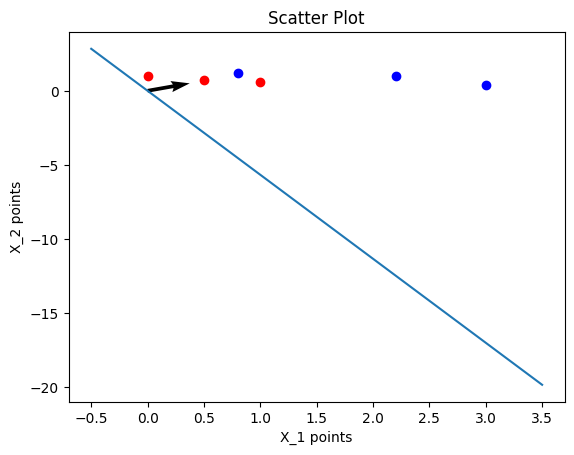

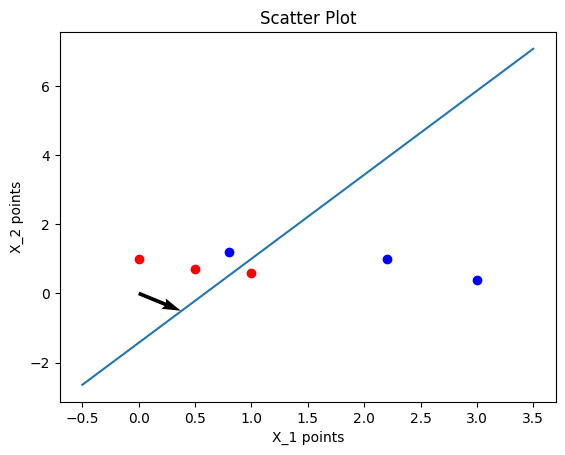

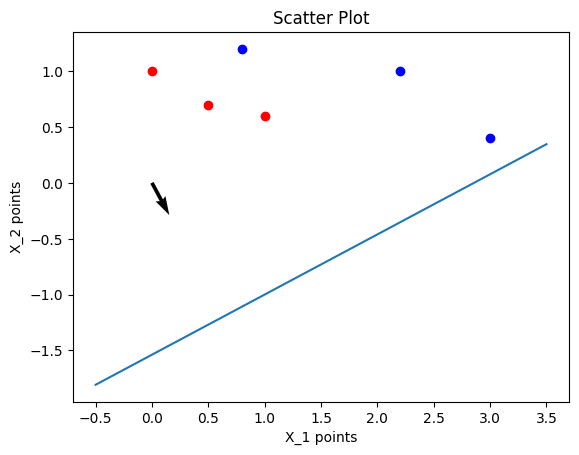

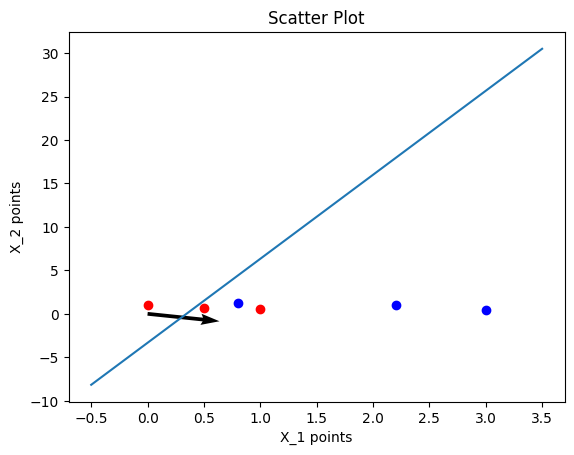

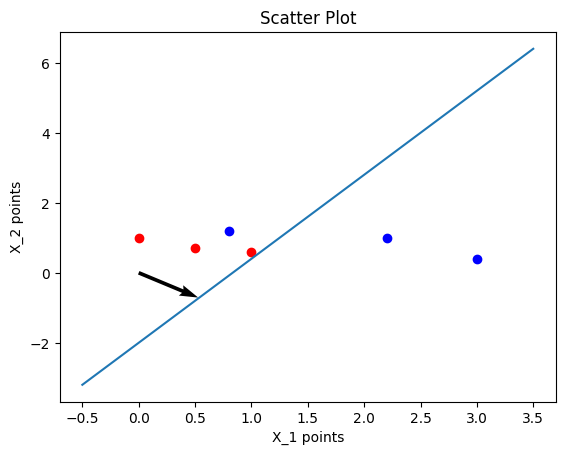

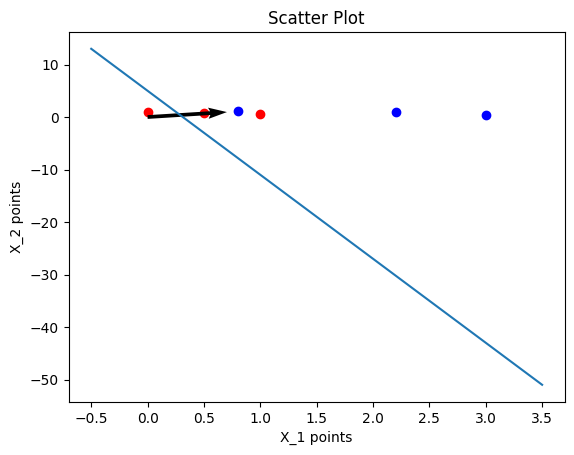

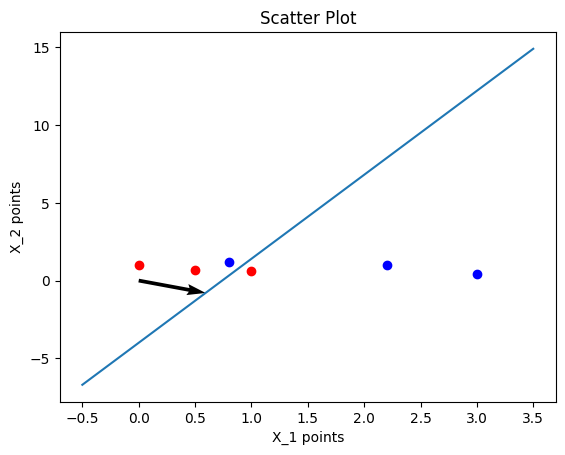

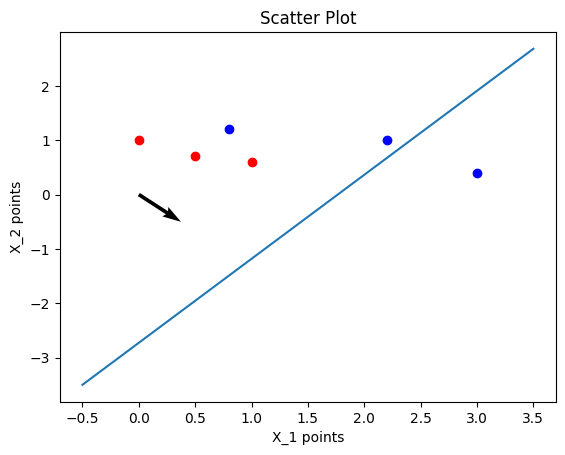

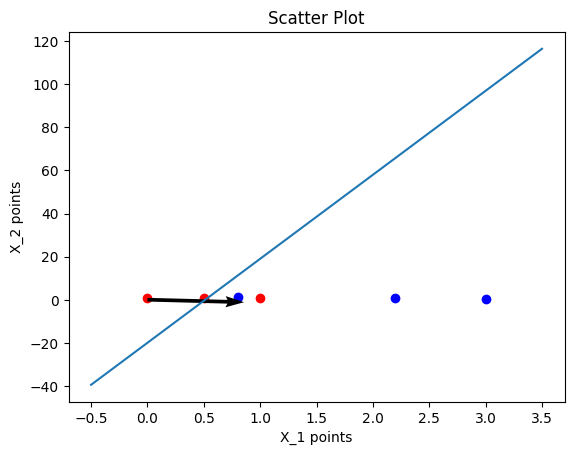

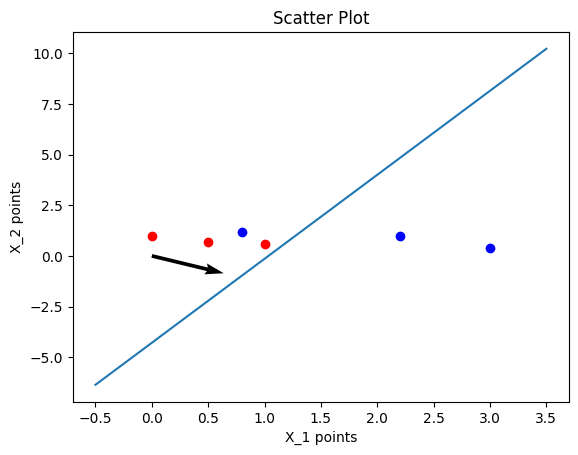

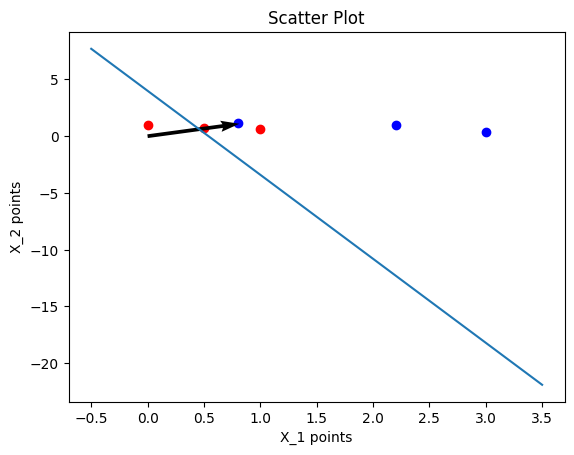

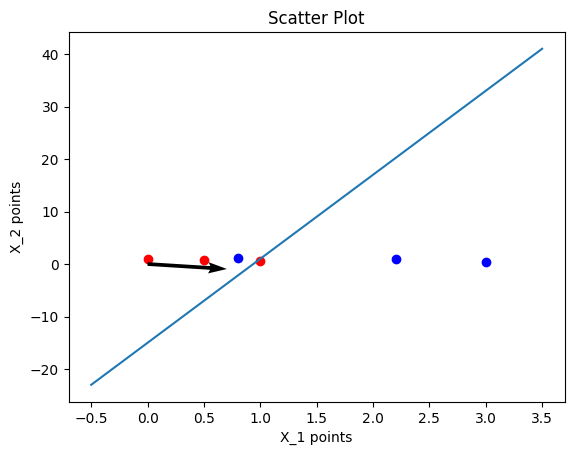

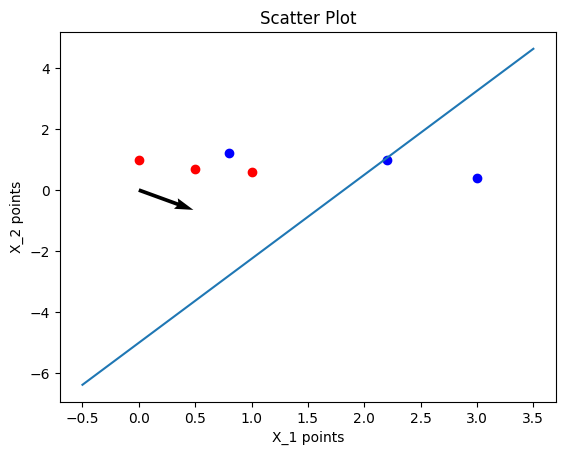

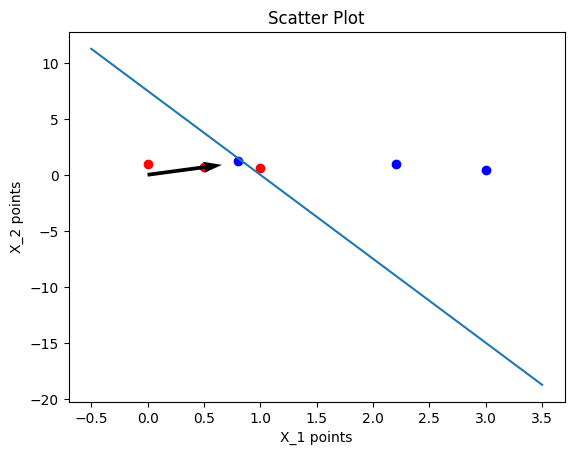

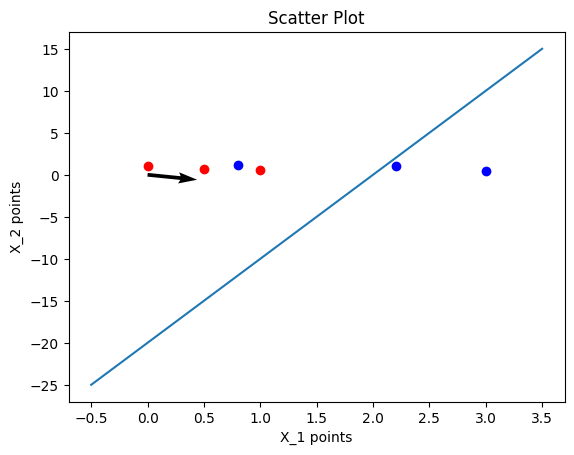

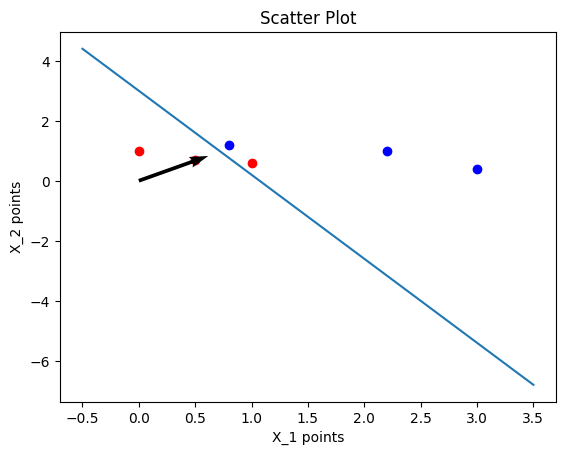

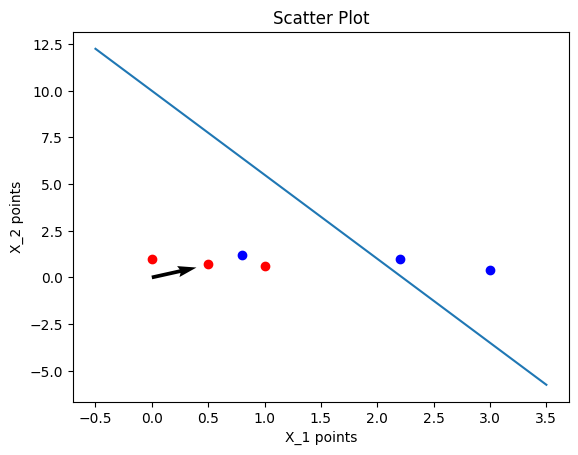

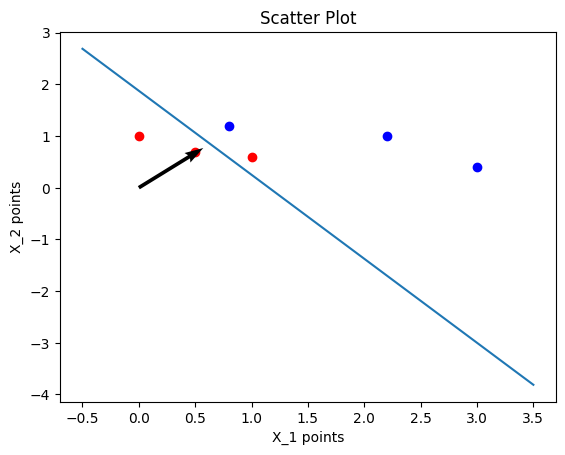

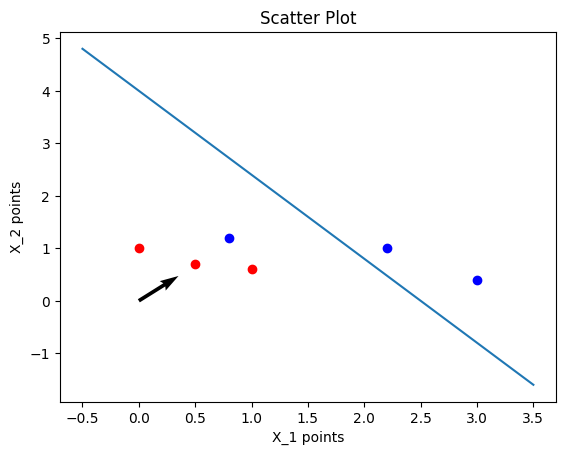

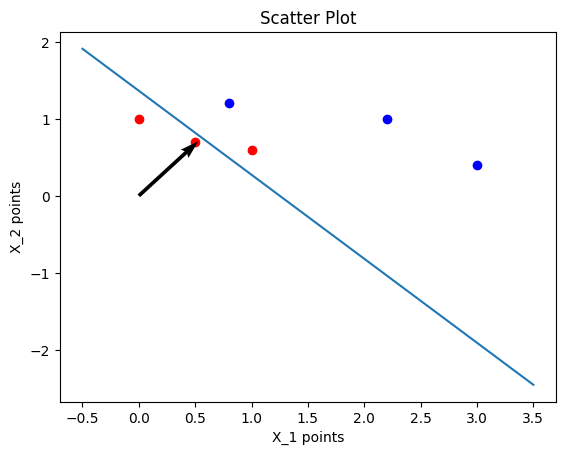

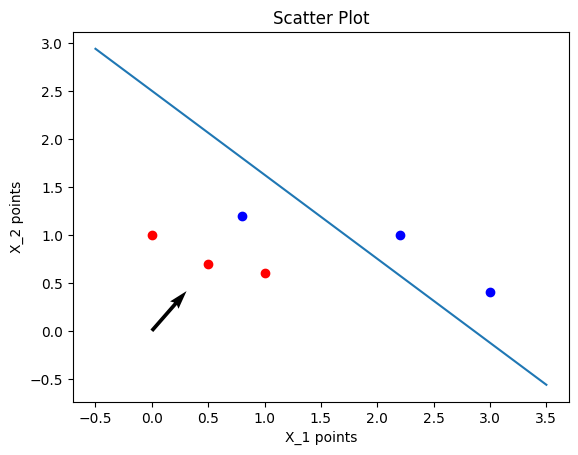

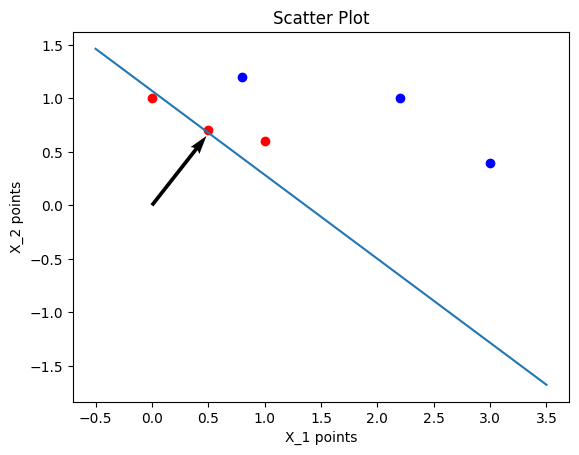

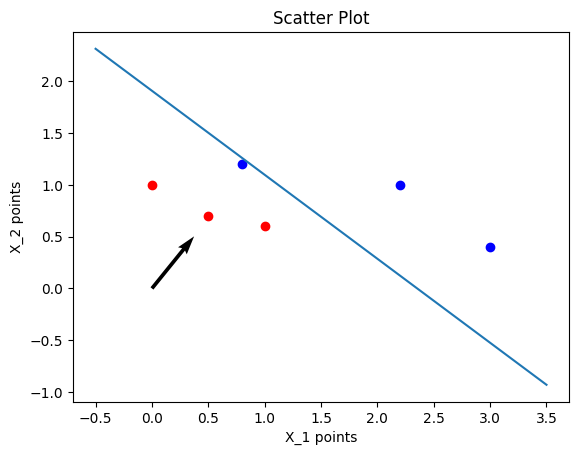

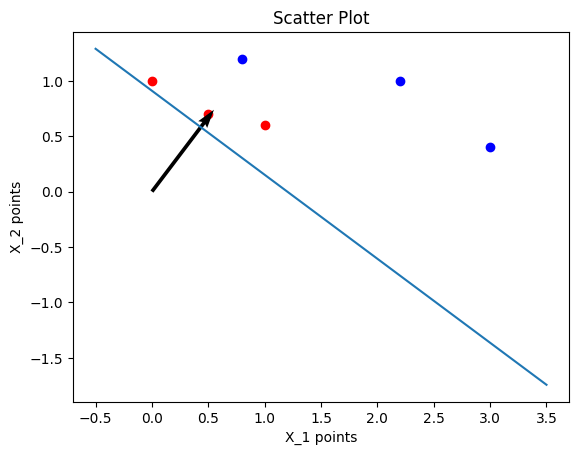

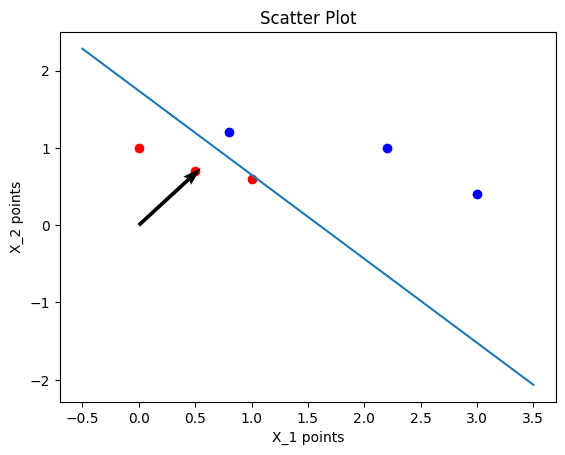

In [ ]:
converged = False
k = 0
while not converged:
  miscalculations= 0
  for values, label in zip(X, y):
      x_augmented = np.concatenate((values, [1]))

      # get predicted label
      y_predict = np.dot(weight_vector, x_augmented)
      if y_predict >= 0:
        y_predict = 1
      else:
        y_predict = -1

      if y_predict != label:
        k+=1
        miscalculations +=1
        weight_vector[:2] += learning_rate * label * x_augmented[:2]
        weight_vector[2] +=  learning_rate * label
        positive_labels = X[y==1]
        negative_labels = X[y==-1]
        plt.scatter(positive_labels[:,0],positive_labels[:,1],color='blue')
        plt.scatter(negative_labels[:,0],negative_labels[:,1],color='red')
        # decision boundary line
        xs = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200)
        ys = -(weight_vector[0]*xs + weight_vector[2]) / (weight_vector[1] + 1e-12)
        plt.plot(xs, ys)
        plt.xlabel("X_1 points")
        plt.ylabel("X_2 points")
        plt.title("Scatter Plot")
        plt.quiver(0,0,weight_vector[0],weight_vector[1],scale=20)
        plt.show()

  if miscalculations == 0:
    converged = True



Part C

Here we compute R

In [ ]:

X_aug = np.hstack([X, np.ones((X.shape[0], 1))])
R = np.linalg.norm(X_aug, axis=1).max()

In [ ]:
print(R)

3.1874754901018454


In [ ]:
w_star = np.array([2,3,-5])

In [ ]:
norm_w_star = np.linalg.norm(w_star)

Here we calculate our margin

In [ ]:
boundary = (y * (X_aug @ w_star)).min() / norm_w_star

In [ ]:
print(boundary)

0.03244428422615239


In [ ]:
theorems_bound = (R/boundary)**2
print(theorems_bound)

9652.000000000067


In [ ]:
print(k)

26


$$
\begin{array}{|l|c|}
\hline
\textbf{Results} & \textbf{Value} \\ \hline
\text{R } & 3.18 \\ \hline
\text{Margin } (\gamma) & 0.03 \\ \hline
\text{Theoretical Bound } (R/\gamma)^2 & 9652 \\ \hline
\text{Actual Mistakes } (k) & 26 \\ \hline
\end{array}
$$

From these results the perceptron convergence theorem holds. The actual number of mistakes was 26 while the theorems bound was 9652, meaning that the bound was not tight because the perceptron converged much earlier than the bound. This likely occured due to the dataset being quite separable and small, thus making it easier to train.

Part D

In [ ]:
X_2 = np.array([
    [2,0],
    [1,0],
    [5,1],
    [0,1],
    [0,2],
    [0,4]
],dtype='float64')
y_2 = np.array([-1,+1,+1,+1,-1,-1],dtype='int')

In [ ]:
# the separating hyperplane
weight_vector_part_d = np.array([1,-1,.5])

[]

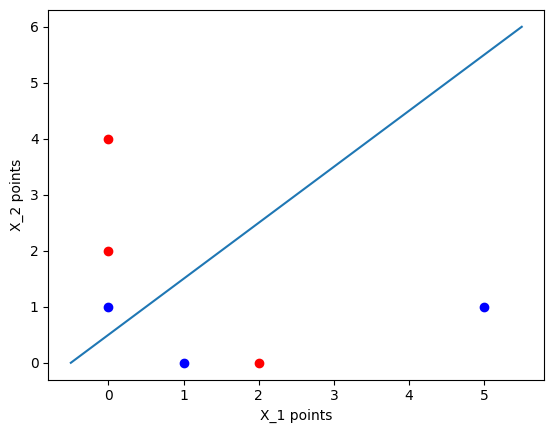

In [ ]:
positive_points = X_2[y_2==1]
negative_points = X_2[y_2==-1]
plt.scatter(positive_points[:,0],positive_points[:,1],color='blue')
plt.scatter(negative_points[:,0],negative_points[:,1],color='red')
plt.xlabel("X_1 points")
plt.ylabel("X_2 points")
xs = np.linspace(X_2[:,0].min()-0.5, X_2[:,0].max()+0.5, 200)
ys = -(weight_vector_part_d[0]*xs + weight_vector_part_d[2]) / (weight_vector_part_d[1] + 1e-12)
plt.plot(xs, ys)
plt.plot()

In [ ]:
weight_vector_train_part_d = np.zeros(3)

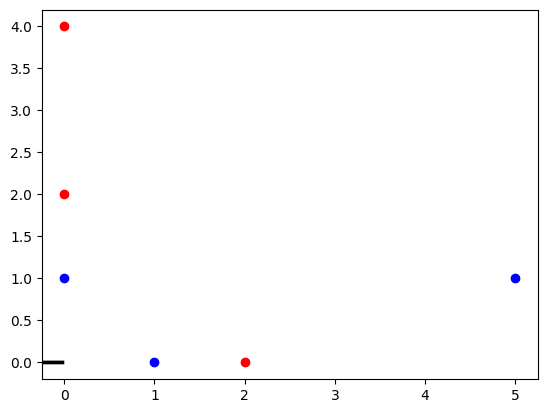

[-2.  0. -1.]


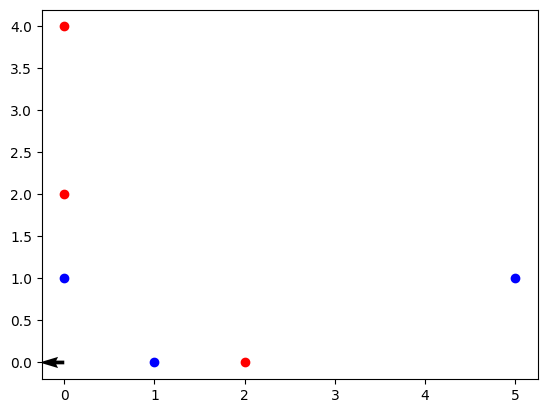

[-1.  0.  0.]


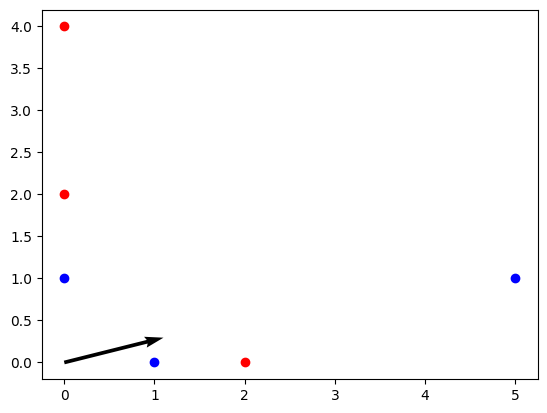

[4. 1. 1.]


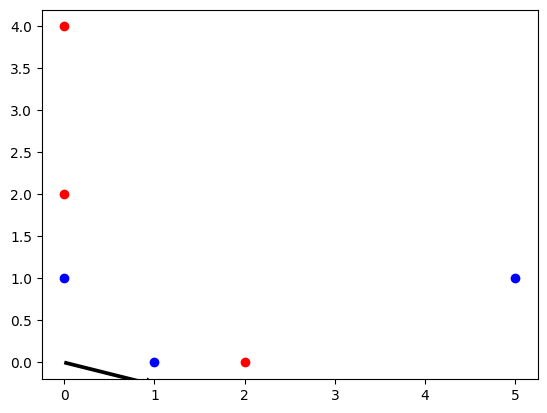

[ 4. -1.  0.]


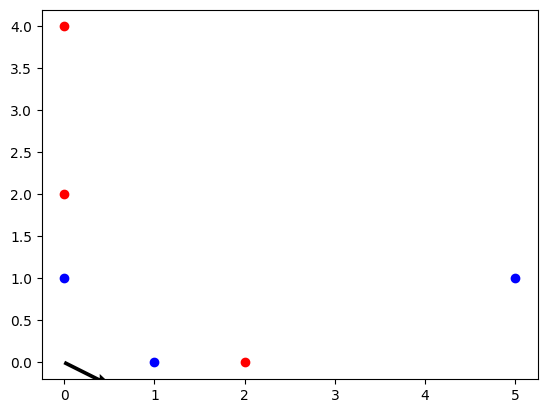

[ 2. -1. -1.]


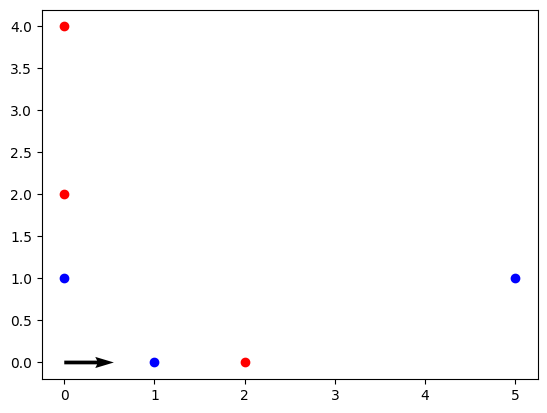

[2. 0. 0.]


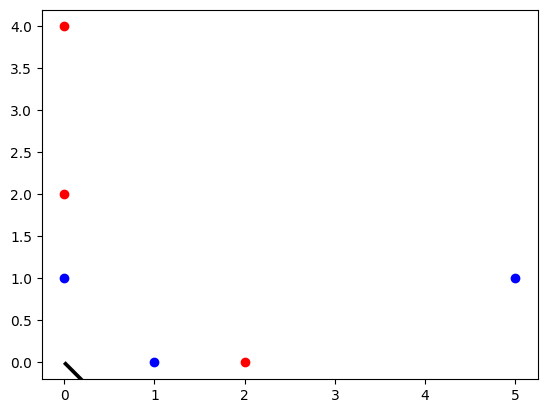

[ 2. -2. -1.]


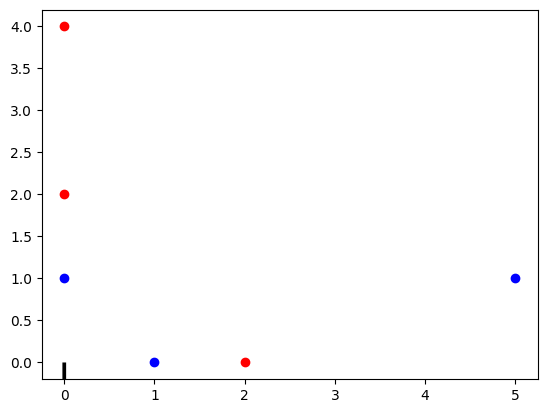

[ 0. -2. -2.]


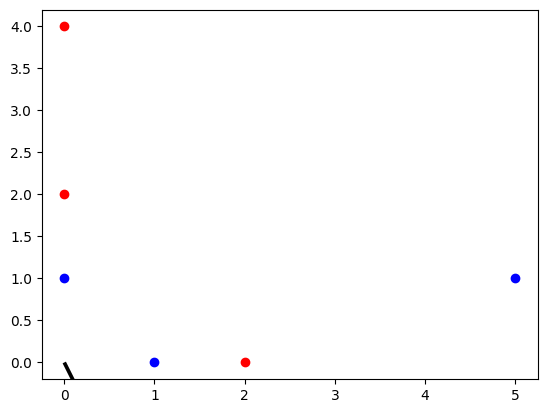

[ 1. -2. -1.]


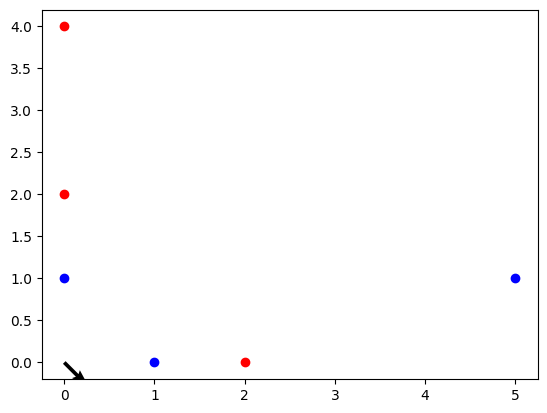

[ 1. -1.  0.]


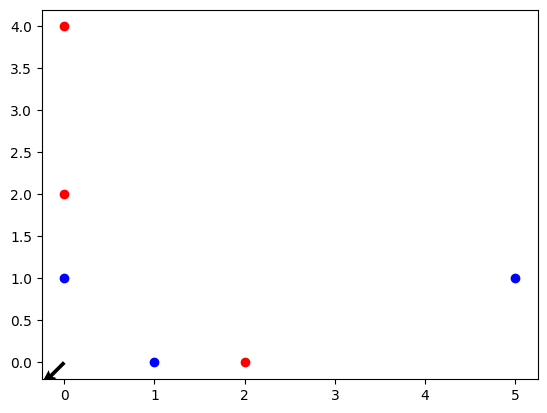

[-1. -1. -1.]


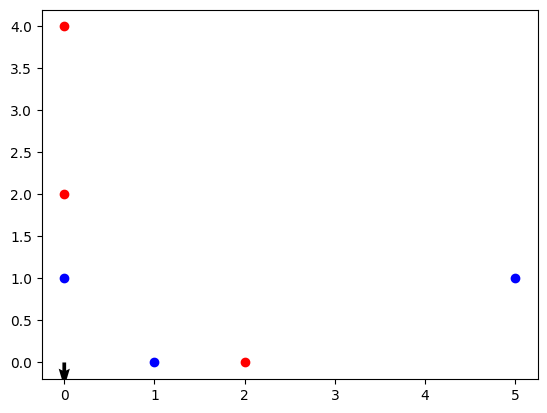

[ 0. -1.  0.]


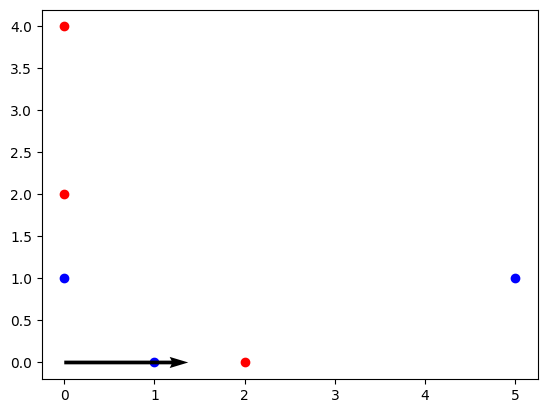

[5. 0. 1.]


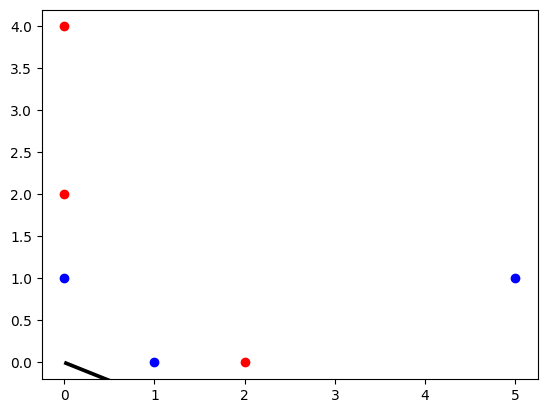

[ 5. -2.  0.]


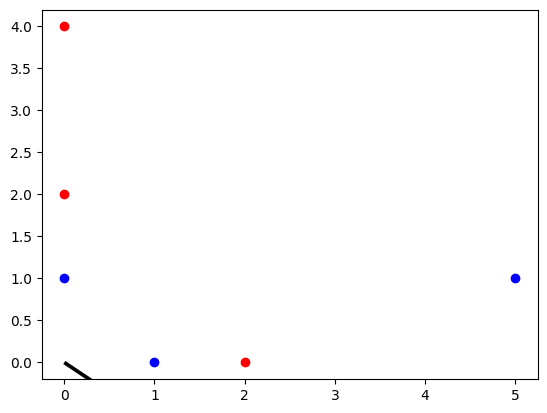

[ 3. -2. -1.]


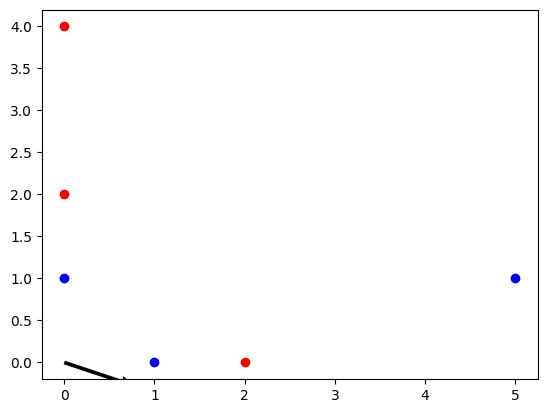

[ 3. -1.  0.]


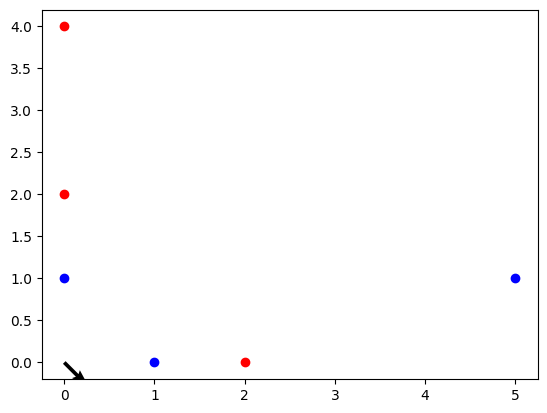

[ 1. -1. -1.]


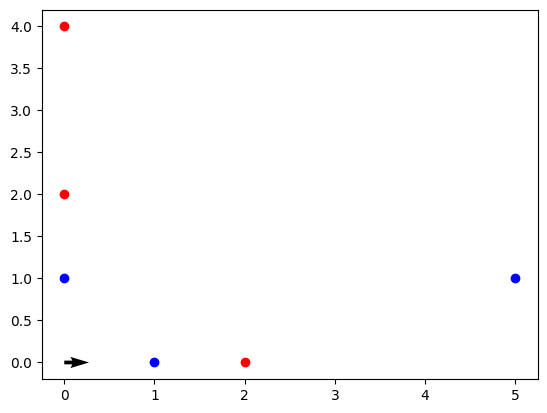

[1. 0. 0.]


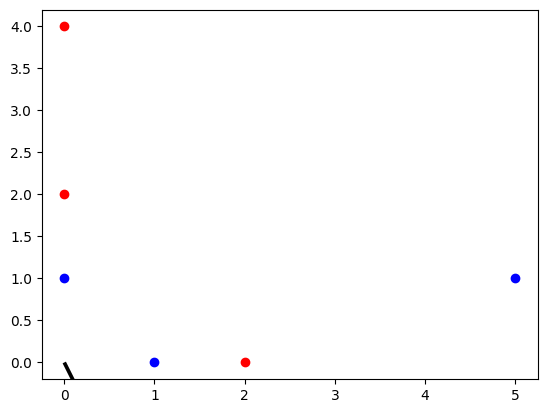

[ 1. -2. -1.]
Cycle found


In [ ]:
converged = False
weights = set()
while not converged:
  miscalculations= 0
  for values, label in zip(X_2, y_2):
      x_augmented = np.concatenate((values, [1]))

      # get predicted label
      y_predict = np.dot(weight_vector_train_part_d, x_augmented)
      if y_predict >= 0:
        y_predict = 1
      else:
        y_predict = -1

      if y_predict != label:

        # we keep track of our previous weights to see
        # if they have already been found
        if tuple(weight_vector_train_part_d) in weights:
          print("Cycle found")
          break
        else:
           weights.add(tuple(weight_vector_train_part_d))

        miscalculations +=1
        weight_vector_train_part_d[:2] += learning_rate * label * x_augmented[:2]
        weight_vector_train_part_d[2] +=  learning_rate * label

        positive_points = X_2[y_2==1]
        negative_points = X_2[y_2==-1]
        plt.scatter(positive_points[:,0],positive_points[:,1],color='blue')
        plt.scatter(negative_points[:,0],negative_points[:,1],color='red')
        plt.quiver(0,0,weight_vector_train_part_d[0],weight_vector_train_part_d[1],scale=20)
        plt.show()
  if miscalculations == 0:
    converged = True

Adding the feature map

In [ ]:
mapped_points = np.array([[i[0],i[1],i[0]*i[1],i[0]**2,i[1]**2] for i in X_2])
mapped_points

array([[ 2.,  0.,  0.,  4.,  0.],
       [ 1.,  0.,  0.,  1.,  0.],
       [ 5.,  1.,  5., 25.,  1.],
       [ 0.,  1.,  0.,  0.,  1.],
       [ 0.,  2.,  0.,  0.,  4.],
       [ 0.,  4.,  0.,  0., 16.]])

In [ ]:
weight_vector_3 = np.zeros(6)

In [ ]:
converged = False
k = 0
while not converged:
  miscalculations= 0
  for values, label in zip(mapped_points, y_2):
      x_augmented = np.concatenate((values, [1]))

      # get predicted label
      y_predict = np.dot(weight_vector_3, x_augmented)
      if y_predict >= 0:
        y_predict = 1
      else:
        y_predict = -1

      if y_predict != label:
        k+=1
        miscalculations +=1
        weight_vector_3 += learning_rate * label * x_augmented
  if miscalculations == 0:
    converged = True

Visualizing the boundary in 2d

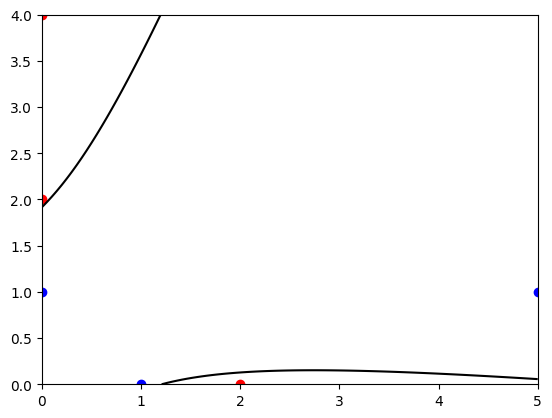

In [ ]:
x_1 = np.linspace(0, 5, 100)
x_2 = np.linspace(0, 4, 100)

X1, X2 = np.meshgrid(x_1, x_2)

Z = (weight_vector_3[0]*X1 + weight_vector_3[1]*X2 + weight_vector_3[2]*(X1*X2) + weight_vector_3[3]*(X1**2) + weight_vector_3[4]*(X2**2) + weight_vector_3[5])

positive_points = X_2[y_2 == 1]
negative_points = X_2[y_2 == -1]
plt.scatter(positive_points[:, 0], positive_points[:, 1], color='blue', label='Positive')
plt.scatter(negative_points[:, 0], negative_points[:, 1], color='red', label='Negative')
plt.contour(X1, X2, Z, levels=[0], colors='black')
plt.show()

Adding the feature map allows us to capture the non-linearities within our dataset. Because our dataset was not linearly separable, simply having two features would could the perceptron to not converge. As it can be seen in the graph, we are able to find a boundary that partitions the points into their intended classes.

Part E

In [ ]:
standardized_X  = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
X_aug_2 = np.hstack([standardized_X, np.ones((X.shape[0], 1))])
R = np.linalg.norm(X_aug_2, axis=1).max()

In [ ]:
weight_vector_train_part_e = np.zeros(3)

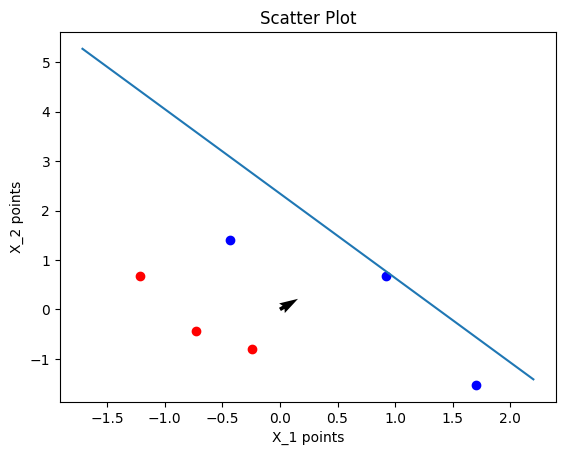

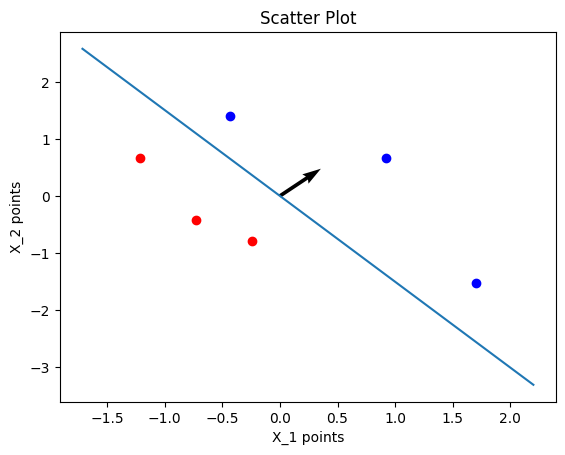

In [ ]:
converged = False
k = 0
while not converged:
  miscalculations= 0
  for values, label in zip(standardized_X, y):
      x_augmented = np.concatenate((values, [1]))

      # get predicted label
      y_predict = np.dot(weight_vector_train_part_e, x_augmented)
      if y_predict >= 0:
        y_predict = 1
      else:
        y_predict = -1

      if y_predict != label:
        k+=1
        miscalculations +=1
        weight_vector_train_part_e[:2] += learning_rate * label * x_augmented[:2]
        weight_vector_train_part_e[2] +=  learning_rate * label
        positive_labels = standardized_X[y==1]
        negative_labels = standardized_X[y==-1]
        plt.scatter(positive_labels[:,0],positive_labels[:,1],color='blue')
        plt.scatter(negative_labels[:,0],negative_labels[:,1],color='red')
        # decision boundary line
        xs = np.linspace(standardized_X[:,0].min()-0.5, standardized_X[:,0].max()+0.5, 200)
        ys = -(weight_vector_train_part_e[0]*xs + weight_vector_train_part_e[2]) / (weight_vector_train_part_e[1] + 1e-12)
        plt.plot(xs, ys)
        plt.xlabel("X_1 points")
        plt.ylabel("X_2 points")
        plt.title("Scatter Plot")
        plt.quiver(0,0,weight_vector_train_part_e[0],weight_vector_train_part_e[1],scale=20)
        plt.show()

  if miscalculations == 0:
    converged = True

In [ ]:
print(f"The number of iterations is {k}")

The number of iterations is 2


In [ ]:
print(f"R is {R}")

R is 2.49295891459938


In [ ]:
norm_w_star_2 = np.linalg.norm(w_star)

In [ ]:
boundary = (y * (X_aug @ w_star)).min() / norm_w_star_2

In [ ]:
theorems_bound = (R/boundary)**2
print(f"The theorems bound is {theorems_bound}")

The theorems bound is 5904.101942386535


Standardizing the features significantly increased the speed of convergence by 24 iterations. This is because the dataset had a much smaller R value due to the standardization, which reduces variability in the updates made to the weight vector. As a result, the number of mistakes needed for convergence is greatly reduced.

Resources Used:

*   https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote03.html
*   https://www.geeksforgeeks.org/deep-learning/perceptron-convergence-theorem-in-neural-networks/

*   https://www.geeksforgeeks.org/python/numpy-meshgrid-function/






